<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [5]:
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [6]:
#Count the number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Display the first few duplicate rows to understand their structure.
print(df[df.duplicated()].head())

Number of duplicate rows: 0
Empty DataFrame
Columns: [ResponseId, MainBranch, Age, Employment, RemoteWork, Check, CodingActivities, EdLevel, LearnCode, LearnCodeOnline, TechDoc, YearsCode, YearsCodePro, DevType, OrgSize, PurchaseInfluence, BuyNewTool, BuildvsBuy, TechEndorse, Country, Currency, CompTotal, LanguageHaveWorkedWith, LanguageWantToWorkWith, LanguageAdmired, DatabaseHaveWorkedWith, DatabaseWantToWorkWith, DatabaseAdmired, PlatformHaveWorkedWith, PlatformWantToWorkWith, PlatformAdmired, WebframeHaveWorkedWith, WebframeWantToWorkWith, WebframeAdmired, EmbeddedHaveWorkedWith, EmbeddedWantToWorkWith, EmbeddedAdmired, MiscTechHaveWorkedWith, MiscTechWantToWorkWith, MiscTechAdmired, ToolsTechHaveWorkedWith, ToolsTechWantToWorkWith, ToolsTechAdmired, NEWCollabToolsHaveWorkedWith, NEWCollabToolsWantToWorkWith, NEWCollabToolsAdmired, OpSysPersonal use, OpSysProfessional use, OfficeStackAsyncHaveWorkedWith, OfficeStackAsyncWantToWorkWith, OfficeStackAsyncAdmired, OfficeStackSyncHaveWo

### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [7]:
## Write your code here

# Colums used to identify duplicate values 
pattern_cols = ["MainBranch", "Employment", "RemoteWork"]

# File that share the same pattern 
pattern_duplicates = df[
    df.duplicated(subset=pattern_cols, keep=False)
].sort_values(pattern_cols)

print("Rows sharing duplicate response patterns:", len(pattern_duplicates))
display(pattern_duplicates[pattern_cols + ["ResponseId"]].head(20))

# Quentitiy of participant per pattern 
pattern_counts = (
    df.groupby(pattern_cols, dropna=False)
      .size()
      .reset_index(name="RespondentCount")
      .query("RespondentCount > 1")
      .sort_values("RespondentCount", ascending=False)
)

display(pattern_counts.head(10))

Rows sharing duplicate response patterns: 65270


,MainBranch,Employment,RemoteWork,ResponseId
12,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",13
14,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15
15,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",16
18,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",19
19,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",20
23,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",24
25,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",26
31,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",32
33,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",34
44,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",45


,MainBranch,Employment,RemoteWork,RespondentCount
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15286
2,I am a developer by profession,"Employed, full-time",Remote,12191
1,I am a developer by profession,"Employed, full-time",In-person,7118
82,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2814
9,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754
244,I am learning to code,"Student, full-time",NaN,1542
280,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",1479
111,I am a developer by profession,"Not employed, but looking for work",NaN,1307
456,I code primarily as a hobby,"Student, full-time",NaN,1273
7,I am a developer by profession,"Employed, full-time;Independent contractor, fr...","Hybrid (some remote, some in-person)",1168


In [8]:
#Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   

groups = df.groupby(pattern_cols, dropna=False)
other_cols = [col for col in df.columns if col not in pattern_cols + ["ResponseId"]]

results = []

for col in other_cols:
    identical_groups = groups[col].nunique(dropna=False).eq(1).sum()
    total_groups = groups.ngroups

    results.append({
        "Column": col,
        "IdenticalGroups": identical_groups,
        "Percentage": identical_groups / total_groups * 100
    })

analysis = (
    pd.DataFrame(results)
      .sort_values("Percentage", ascending=False)
)

display(analysis.head(20))

,Column,IdenticalGroups,Percentage
1,Check,561,100.000000
71,AINextMuch less integrated,416,74.153298
108,ConvertedCompYearly,402,71.657754
13,BuildvsBuy,392,69.875223
17,CompTotal,388,69.162210
11,PurchaseInfluence,387,68.983957
10,OrgSize,383,68.270945
16,Currency,376,67.023173
12,BuyNewTool,373,66.488414
14,TechEndorse,373,66.488414


### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


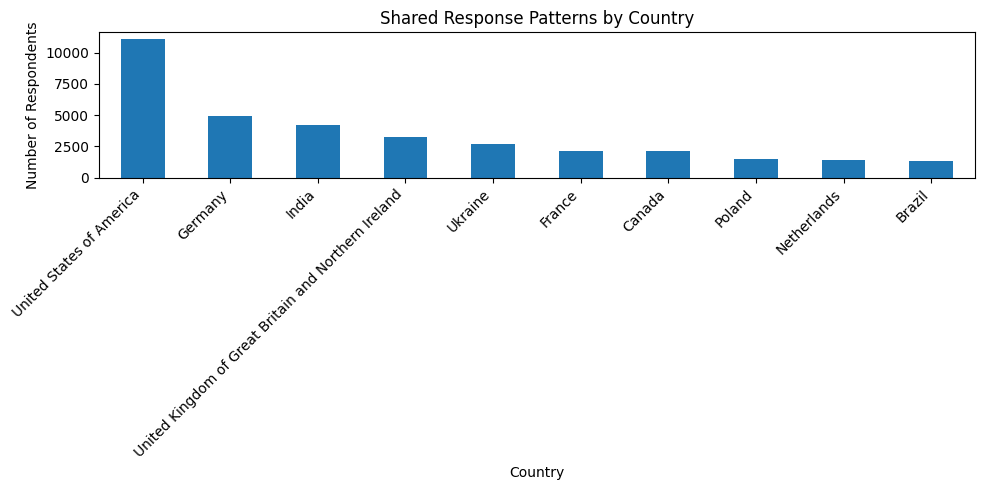

In [9]:
## Create visualizations to show the distribution of shared response patterns across different categories.

import matplotlib.pyplot as plt

pattern_cols = ["MainBranch", "Employment", "RemoteWork"]

# Seleccionar todos los registros que comparten el mismo patrón
shared_patterns = df[
    df.duplicated(subset=pattern_cols, keep=False)
]

# Top 10 países con más respuestas compartidas
country_counts = shared_patterns["Country"].value_counts().head(10)

country_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Shared Response Patterns by Country")
plt.xlabel("Country")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

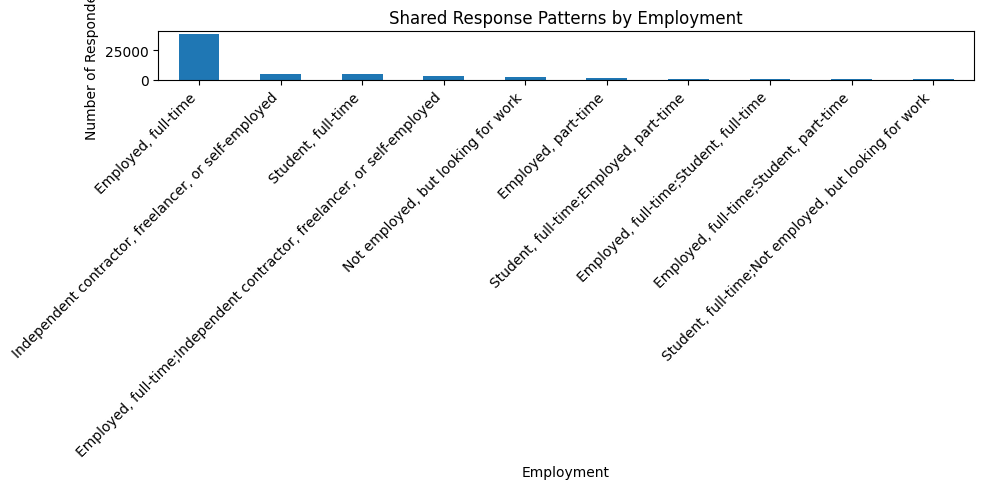

In [10]:
#Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.
employment_counts = shared_patterns["Employment"].value_counts().head(10)

employment_counts.plot(kind="bar", figsize=(10, 5))
plt.title("Shared Response Patterns by Employment")
plt.xlabel("Employment")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

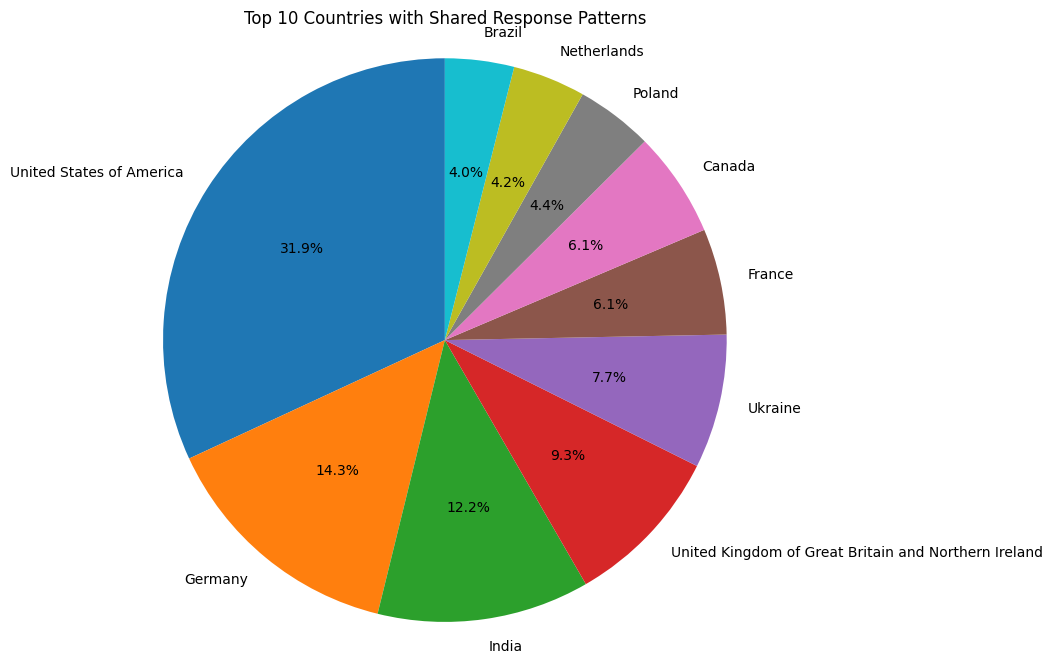

In [11]:
country_counts = shared_patterns["Country"].value_counts().head(10)

plt.figure(figsize=(8, 8))
plt.pie(
    country_counts,
    labels=country_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Top 10 Countries with Shared Response Patterns")
plt.axis("equal")
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


### Analysis

- The 'ResponseId'column uniquely identifies each survey response, making it the primary column that defines record uniqueness.
- No fully duplicated rows were found in the dataset (`df.duplicated().sum() == 0`), indicating that each record corresponds to a different respondent.
- Although many respondents share the same values for `MainBranch`, `Employment`, and `RemoteWork`, these are common response patterns rather than duplicate records.
- Therefore, removing rows based only on these columns would incorrectly eliminate valid responses from different participants.
- For this survey dataset, duplicate removal should only be considered when complete rows are duplicated or when duplicate `ResponseId` values are detected.

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


We identified duplicate records using the `duplicated()` method in pandas. The analysis showed that there were no fully duplicated rows in the dataset. We also examined duplicate response patterns based on the `MainBranch`, `Employment`, and `RemoteWork` columns. Since these patterns represent different respondents with similar answers rather than duplicate records, no rows were removed from the dataset.

2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


The `ResponseId` column was used to determine record uniqueness because it uniquely identifies each survey response. The `MainBranch`, `Employment`, and `RemoteWork` columns were selected to analyze shared response patterns, not to identify duplicate records. Removing rows based only on these columns would eliminate valid responses from different participants. Therefore, duplicate removal should only be performed when complete duplicate rows or duplicate `ResponseId` values are found.

### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
